In [1]:
import re
import requests
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os, gc
import torch
from pathlib import Path
import subprocess
import random
import glob
from sentence_transformers import SentenceTransformer
from Bio.Align import PairwiseAligner
from Bio import SeqIO
import faiss

# Fix random seeds for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# =====================================================================
# 不要なヘッダータグなどを除去
# =====================================================================

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\{ECO:[^}]+\}", "", text)
    text = re.sub(r"\(\s*PubMed:[^)]+\)", "", text)
    text = re.sub(r"\(By similarity\)", "", text)
    text = re.sub(r"\[GO:\d+\]", "", text)
    text = re.sub(r"(?:Xref|Evidence|Note|EC)=\s*[^;]*(?:;|$)", "", text, flags=re.IGNORECASE)
    text = re.sub(r"(?:Reaction)=\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^(?:FUNCTION|CATALYTIC ACTIVITY|KEYWORDS|SIMILARITY|SUBCELLULAR LOCATION):\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\.;", ".", text)
    text = re.sub(r"\s+\.", ".", text)
    text = re.sub(r"\.\s*\.", ".", text)
    text = re.sub(r"\.+", ".", text)
    text = re.sub(r"\s+,", ",", text)
    text = re.sub(r"\s*;", "; ", text)
    text = re.sub(r"(;\s*){2,}", "; ", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip(" ;").strip()

def clean_text_to_sentences(text):
    if not text:
        return []
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"\[+cite:[\s\S]*?\]+", "", text)
    text = re.sub(r"\]\s*,\s*\[(?=cite:)", "", text)
    text = re.sub(r"(?<=cite:[^\]])\]\s*,\s*\[", "", text)
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r",(?:\s*,)+", ",", text)
    text = re.sub(r",\s*\.", ".", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s+\.", ".", text)
    text = re.sub(r"\s+,", ",", text)
    sentences = [s.strip() for s in re.split(r"\.(?=\s|$)", text) if s.strip()]
    return sentences

In [ ]:
# =====================================================================
# InterProのTSVデータをキャッシュ（辞書化）する関数の定義
# =====================================================================
def load_interpro_cache(interpro_tsv_path):
    if not os.path.exists(interpro_tsv_path):
        print(f"[警告] InterPro TSVファイルが見つかりません: {interpro_tsv_path}")
        return {}
    
    print(f"InterPro データをキャッシュにロード中: {interpro_tsv_path}")
    df_ip = pd.read_csv(interpro_tsv_path, sep="\t").fillna("")
    
    cache = {}
    for _, row in df_ip.iterrows():
        uniprot_id = row["Entry"]
        cache[uniprot_id] = {
            "superfamilies": [x.strip() for x in str(row.get("InterPro_Superfamily", "")).split("||") if x.strip()],
            "families": [x.strip() for x in str(row.get("InterPro_Family", "")).split("||") if x.strip()],
            "domains": [x.strip() for x in str(row.get("InterPro_Domain", "")).split("||") if x.strip()],
            "repeats": [x.strip() for x in str(row.get("InterPro_Repeat", "")).split("||") if x.strip()],
            "sites": [x.strip() for x in str(row.get("InterPro_Conserved_Site", "")).split("||") if x.strip()]
        }
    print(f"InterPro キャッシュロード完了 ({len(cache)} 件)")
    return cache

In [ ]:
def parse_catalytic_activity_to_list(raw_activity):
    if not isinstance(raw_activity, str) or pd.isna(raw_activity) or not raw_activity.strip():
        return []
    
    raw_sections = re.split(r'(;?\s*CATALYTIC ACTIVITY:\s*|;\s*(?=Reaction=))', raw_activity, flags=re.IGNORECASE)
    activity_lines = []
    
    for section in raw_sections:
        if not section or "Reaction=" not in section:
            continue
            
        rxn_match = re.search(r'Reaction=([^;]+)', section, flags=re.IGNORECASE)
        if not rxn_match:
            continue
            
        rxn_text = clean_text(rxn_match.group(1))
        if not rxn_text:
            continue
            
        dir_matches = re.findall(r'PhysiologicalDirection=([^;]+)', section, flags=re.IGNORECASE)
        directions = [d.strip().lower() for d in dir_matches]
        
        rxn_sentence = f"The protein catalyzes the reaction: {rxn_text}."
        
        has_l2r = any("left-to-right" in d for d in directions)
        has_r2l = any("right-to-left" in d for d in directions)
        
        if has_l2r and has_r2l:
            direction_sentence = "This reaction is bidirectional."
        elif has_r2l:
            direction_sentence = "The physiological direction of this reaction is right-to-left."
        elif has_l2r:
            direction_sentence = "The physiological direction of this reaction is left-to-right."
        else:
            direction_sentence = ""
            
        if direction_sentence:
            activity_lines.append(f"{rxn_sentence} {direction_sentence}")
        else:
            activity_lines.append(rxn_sentence)
                
    return activity_lines

In [ ]:
def generate_membrane_topology(seq_len, transmembrane_val, topo_domain_val):
    topology = ['n'] * seq_len
    if isinstance(topo_domain_val, str) and topo_domain_val:
        matches = re.finditer(r'TOPO_DOM\s+(\d+)\.\.(\d+);\s*/note="([^"]+)"', topo_domain_val)
        for match in matches:
            start = int(match.group(1))
            end = int(match.group(2))
            note = match.group(3).lower() 
            
            if any(x in note for x in ["periplasmic", "intermembrane", "perinuclear"]):
                state = 'b'
            elif any(x in note for x in ["cytoplasmic", "intracellular", "mitochondrial matrix", "stromal", "nuclear", "intravirion", "mother cell"]):
                state = 'i'
            elif any(x in note for x in ["extracellular", "lumenal", "vesicle", "vesicular", "vacuolar", "intravacuolar", "thylakoid", "exoplasmic", "peroxisomal", "virion surface"]):
                state = 'o'
            else:
                state = 'n'
                
            for i in range(max(0, start - 1), min(seq_len, end)):
                topology[i] = state

    if isinstance(transmembrane_val, str) and transmembrane_val:
        matches = re.finditer(r'TRANSMEM\s+(\d+)\.\.(\d+)', transmembrane_val)
        for match in matches:
            start = int(match.group(1))
            end = int(match.group(2))
            for i in range(max(0, start - 1), min(seq_len, end)):
                topology[i] = 'm'

    return "".join(topology)

In [ ]:
# =====================================================================
# [機能追加・適応] 各ヘッダー別にデータを切り分けて取得する関数
# =====================================================================
def extract_feature_by_headers(row, interpro_cache=None):
    """
    最終的なProLLaMA入力テキストではなく
    各[ヘッダー名]をキーとした辞書形式で処理結果を返します。
    """
    # 1. 基本情報の取得とクレンジング
    uniprot_id = row.get('Entry', '')
    seq = row.get('Sequence', '')
    seq_len = int(row.get('Length', len(seq))) if pd.notna(row.get('Length')) else len(seq)
    
    function_raw = clean_text(row.get('Function [CC]', ''))
    function_text = f"{function_raw}." if function_raw and not function_raw.endswith('.') else function_raw
    
    uniprot_family_raw = clean_text(row.get('Sequence similarities', ''))
    uniprot_family = f"{uniprot_family_raw}." if uniprot_family_raw and not uniprot_family_raw.endswith('.') else uniprot_family_raw
    
    subcellular_raw = clean_text(row.get('Subcellular location [CC]', ''))
    subcellular = subcellular_raw.replace(" ;", ";")
    
    catalytic_lines = parse_catalytic_activity_to_list(row.get('Catalytic activity', ''))
    
    # 2. GOアノテーションを取得
    def parse_go_column(col_name):
        go_terms = row.get(col_name, '')
        if isinstance(go_terms, str) and go_terms:
            go_names = [g.split('[')[0].strip() for g in go_terms.split(';') if g.strip()]
            return "; ".join(go_names)
        return ""

    go_cc_text = parse_go_column('Gene Ontology (cellular component)')
    go_bp_text = parse_go_column('Gene Ontology (biological process)')
    go_mf_text = parse_go_column('Gene Ontology (molecular function)')

    # 3. InterPro情報の取得 (キャッシュ参照)
    superfamilies, families, domains, repeats, sites = [], [], [], [], []
    if interpro_cache is not None and uniprot_id in interpro_cache:
        ip_data = interpro_cache[uniprot_id]
        superfamilies = ip_data["superfamilies"]
        families = ip_data["families"]
        domains = ip_data["domains"]
        repeats = ip_data["repeats"]
        sites = ip_data["sites"]

    # 4. 膜トポロジー文字列の生成
    tm_val = row.get('Transmembrane', '')
    td_val = row.get('Topological domain', '')
    topology_str = generate_membrane_topology(seq_len, tm_val, td_val)

    # 5. カラムごとに切り分けた辞書を構築
    # ※ 複数要素がある項目は改行(\n)で連結。中身がない場合は空文字に設定
    feature_dict = {}
    
    feature_dict["[FUNCTION]"] = function_text if function_text else ""
    
    # InterPro 各セクション
    feature_dict["[INTERPRO SUPERFAMILY]"] = "\n".join(superfamilies) if superfamilies else ""
    feature_dict["[INTERPRO FAMILY]"] = "\n".join(families) if families else ""
    feature_dict["[INTERPRO DOMAIN]"] = "\n".join(domains) if domains else ""
    feature_dict["[INTERPRO REPEAT]"] = "\n".join(repeats) if repeats else ""
    feature_dict["[INTERPRO CONSERVED SITE]"] = "\n".join(sites) if sites else ""
        
    feature_dict["[UNIPROT FAMILY]"] = uniprot_family if uniprot_family else ""
    
    # Catalytic Activity
    feature_dict["[CATALYTIC ACTIVITY]"] = "\n".join(catalytic_lines) if catalytic_lines else ""
        
    feature_dict["[SUBCELLULAR LOCATION]"] = subcellular if subcellular else ""
        
    # 膜トポロジー記述
    if topology_str:
        feature_dict["[MEMBRANE TOPOLOGY]"] = (
            f"The structural topology of the generated sequence is represented by a lowercase string of the same length as the sequence. "
            f"'m', 'i', 'o', 'b', and 'n' represent transmembrane, inside (cytoplasmic/matrix), outside (extracellular/lumenal), between (intermembrane/periplasmic space), and unknown or unspecified positions, respectively. "
            f"The structural topology is as follows:\n"
            f"{topology_str}"
        )
    else:
        feature_dict["[MEMBRANE TOPOLOGY]"] = ""
        
    feature_dict["[GENE ONTOLOGY CELLULAR COMPONENT]"] = go_cc_text if go_cc_text else ""
    feature_dict["[GENE ONTOLOGY BIOLOGICAL PROCESS]"] = go_bp_text if go_bp_text else ""
    feature_dict["[GENE ONTOLOGY MOLECULAR FUNCTION]"] = go_mf_text if go_mf_text else ""
        
    feature_dict["[SEQUENCE LENGTH]"] = f"The generated protein sequences should have a length of approximately {seq_len} residues."
    
    return feature_dict

In [ ]:
# =====================================================================
# メインの実行処理
# =====================================================================
tsv_path = "data/processed_data/uniprot_preprocessed_2026_07_14.tsv"
interpro_desc_tsv_path = "data/processed_data/uniprot_preprocessed_2026_07_14_InterPro_description.tsv"

try:
    df_dataset = pd.read_csv(tsv_path, sep='\t')
    print(f"データセット '{tsv_path}' を正常に読み込みました。(全 {len(df_dataset)} 行)")
    
    ip_cache = load_interpro_cache(interpro_desc_tsv_path)
    
    # 各ヘッダーの値を蓄積するためのリストを辞書で用意
    headers = [
        "[FUNCTION]", "[INTERPRO SUPERFAMILY]", "[INTERPRO FAMILY]", 
        "[INTERPRO DOMAIN]", "[INTERPRO REPEAT]", "[INTERPRO CONSERVED SITE]",
        "[UNIPROT FAMILY]", "[CATALYTIC ACTIVITY]", "[SUBCELLULAR LOCATION]", 
        "[MEMBRANE TOPOLOGY]", "[GENE ONTOLOGY CELLULAR COMPONENT]", 
        "[GENE ONTOLOGY BIOLOGICAL PROCESS]", "[GENE ONTOLOGY MOLECULAR FUNCTION]",
        "[SEQUENCE LENGTH]"
    ]
    
    accumulated_data = {h: [] for h in headers}
    
    print("\n--- 各行のデータをヘッダーごとに分割抽出中 ---")
    for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Extracting features"):
        row_dict = row.to_dict()
        row_features = extract_feature_by_headers(row_dict, interpro_cache=ip_cache)
        
        # 辞書の各ヘッダー項目をそれぞれのカラム用リストに追加
        for h in headers:
            accumulated_data[h].append(row_features[h])
            
    # データフレームに「[HEADER]」という名前の独立したカラムとして一括追加
    print("\nデータフレームに新規カラムを追加しています...")
    for h in headers:
        df_dataset[h] = accumulated_data[h]
    
    # 完成したTSVファイルを保存
    output_path = "data/processed_data/uniprot_preprocessed_2026_07_14_description.tsv"
    df_dataset.to_csv(output_path, sep="\t", index=False)
    print(f"\n[処理完了] ヘッダー別のカラムを追加したTSVを保存しました: {output_path}")

    # =====================================================================
    # 検証：特定のUniProt IDでカラムが分かれているか確認
    # =====================================================================
    target_id = "P0AAD8"
    target_row = df_dataset[df_dataset['Entry'] == target_id]
    
    if not target_row.empty:
        print(f"\n=== [統合後の分割カラム検証結果 (UniProt ID: {target_id})] ===")
        row_sample = target_row.iloc[0]
        for h in headers:
            val = row_sample[h]
            # 中身がある項目のみピックアップして表示
            if val:
                print(f"{h}:\n{val}")
                print("-" * 40)
    else:
        print(f"\n[確認] 検証用ID '{target_id}' はデータセットに存在しませんでした。")
        
except FileNotFoundError as e:
    print(f"[エラー] 必要なファイルが見つかりません。パスを確認してください。\n詳細: {e}")

In [ ]:
def create_protein_description_column(input_tsv_path, output_tsv_path, selected_headers):
    """
    分割TSVファイルを読み込み、選択されたヘッダーカラムから最終記述を組み立てて
    ["Protein description"] カラムを追加した新しいTSVを保存する関数。
    """
    print(f"データを読み込み中: {input_tsv_path}")
    df = pd.read_csv(input_tsv_path, sep='\t').fillna("")
    
    protein_descriptions = []
    
    print("\n--- 選択されたカラムから 'Protein description' を組み立て中 ---")
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Building descriptions"):
        lines = []
        
        # ユーザーが選択したヘッダー（カラム名）を順番に走査
        for header in selected_headers:
            if header not in df.columns:
                continue
                
            cell_value = str(row[header]).strip()
            if not cell_value:
                continue  # 中身がない場合はスキップ（出力しない）
            
            # セル内に改行(\n)が含まれている場合、分割してそれぞれにヘッダーを付与
            sub_lines = cell_value.split('\n')
            for sub_line in sub_lines:
                sub_line_clean = sub_line.strip()
                if sub_line_clean:
                    lines.append(f"{header} {sub_line_clean}")
        
        # 行ごとに組み立てたテキストを改行で結合して格納
        final_text = "\n".join(lines)
        protein_descriptions.append(final_text)
        
    # 新しいカラム ["Protein description"] としてデータフレームに追加
    df["Protein description"] = protein_descriptions
    
    # TSVとして保存
    df.to_csv(output_tsv_path, sep='\t', index=False)
    print(f"\n[処理完了] 新規カラムを追加したTSVを保存しました:\n--> {output_tsv_path}")
    
    return df

# =====================================================================
# ユーザー設定領域（プロンプトに使いたいカラムを選択）
# =====================================================================
# 前ステップで保存した、ヘッダーごとにカラムが分かれているTSVのパス
input_split_tsv = "data/processed_data/uniprot_preprocessed_2026_07_14_description.tsv"
# 最終的な出力ファイルの保存先パス
output_final_tsv = "data/processed_data/uniprot_final_2026_07_14_dataset.tsv"

# 後からユーザーが「どの項目を入力記述に使うか」をここで自由に変更・選択できます
user_selected_headers = [
    "[FUNCTION]",
    "[INTERPRO SUPERFAMILY]",
    "[INTERPRO FAMILY]",
    "[INTERPRO DOMAIN]",
    "[INTERPRO REPEAT]",
    "[INTERPRO CONSERVED SITE]",
    "[UNIPROT FAMILY]",
    "[CATALYTIC ACTIVITY]",
    "[SUBCELLULAR LOCATION]",
    #"[MEMBRANE TOPOLOGY]",
    "[GENE ONTOLOGY CELLULAR COMPONENT]",
    "[GENE ONTOLOGY BIOLOGICAL PROCESS]",
    "[GENE ONTOLOGY MOLECULAR FUNCTION]",
    "[SEQUENCE LENGTH]"
]

# =====================================================================
# 実行処理
# =====================================================================
if __name__ == "__main__":
    # 変換および保存を実行
    df_result = create_protein_description_column(input_split_tsv, output_final_tsv, user_selected_headers)
    
    # 検証用：特定のIDで "Protein description" の中身が正しく作られているかプレビュー表示
    target_id = "P0AAD8" 
    target_row = df_result[df_result['Entry'] == target_id]
    
    if not target_row.empty:
        print(f"\n=== [検証: {target_id} の 'Protein description' カラム最終出力] ===")
        print(target_row.iloc[0]["Protein description"])
        print("=" * 60)

続き

In [2]:
ProTrek_650M_UniRef50_temperature = 0.0186767578

os.environ['JUPYTER_DISABLE_WIDGETS'] = '1'
print("[Info] Loading encoder...")

protein_encoder = SentenceTransformer("yosshstd/ProTrek_650M_UniRef50_protein_encoder")
text_encoder = SentenceTransformer("yosshstd/ProTrek_650M_UniRef50_text_encoder")

[Info] Loading encoder...


Loading weights:   0%|          | 0/568 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [4]:
# 1. ランダムに1行抽出
uniprot_with_des_tsv_path = "data/processed_data/uniprot_final_2026_07_14_dataset.tsv" 
df = pd.read_csv(uniprot_with_des_tsv_path, sep='\t')

df_reviewed = df[df['Reviewed'] == 'reviewed']
df_unreviewed_reps = df[df['Reviewed'] == 'unreviewed']

sample_rows = df_unreviewed_reps.sample(1)

for _, row in sample_rows.iterrows():
    # データの取得
    entry_id = row['Entry']
    sequence = row['Sequence']
    description = row['Protein description']

    # --- 情報の表示 ---
    print(f"ID: {entry_id}")
    print(f"Sequence:\n{sequence}")
    print("----")
    print(f"Description:\n{description}")
    print("----")

    # 2. エンコーディング (リスト形式で渡す)
    # DescriptionとSequenceをそれぞれベクトル化
    text_vec = text_encoder.encode([description], convert_to_numpy=True)
    seq_vec = protein_encoder.encode([sequence], convert_to_numpy=True)

    # 3. スコア計算
    # 内積をとり、Temperatureでスケーリング
    raw_dot_product = np.dot(seq_vec, text_vec.T)[0][0]
    score = raw_dot_product / ProTrek_650M_UniRef50_temperature

    print(f"Seq-Text ProTrek Score: {score:.4f}")

/tmp/ipykernel_2278761/1216683287.py:3: DtypeWarning: Columns (0: Pathway, 1: Catalytic activity, 2: Gene Names (synonym), 3: Virus hosts, 4: Sequence caution, 5: Sequence conflict, 6: Sequence uncertainty, 7: RNA Editing, 8: Polymorphism, 9: Non-terminal residue, 10: Natural variant, 11: Mass spectrometry, 12: Alternative sequence, 13: Erroneous gene model prediction, 14: Redox potential, 15: Rhea ID, 16: Site, 17: Temperature dependence, 18: pH dependence, 19: Kinetics, 20: Activity regulation, 21: EC number, 22: Absorption, 23: Active site, 24: Binding site, 25: Cofactor, 26: DNA binding, 27: Miscellaneous [CC], 28: Subunit structure, 29: Interacts with, 30: Tissue specificity, 31: Induction, 32: Developmental stage, 33: Involvement in disease, 34: Mutagenesis, 35: Pharmaceutical use, 36: Toxic dose, 37: Allergenic Properties, 38: Biotechnological use, 39: Disruption phenotype, 40: Topological domain, 41: Intramembrane, 42: Cross-link, 43: Disulfide bond, 44: Glycosylation, 45: Modi

ID: A0AAU9EF95
Sequence:
MAVRKKVLGQIILVVVLLVAGTAALAAFVLSKKPPARKTAQVVSPLVRVMEVASRPVEVTVQGEGTVIPMTQPVLSAEVAGRVVYVSPHLVAGGSFKQGELLLKIEQRDYQLALTLAQASVKAAETSLQTTREEAASAREEWHLLNKDSDNKMGEPPSLLIKEPQIAQYKSSLEAAKAQVEQARLNLARTEVRAPFDGRVVAENVDLGQYLAKGGVIATVFSTEAAEINVYIEDHDLAWLNVPGLTTHDKQGSPAVVSAEFAGKQMSWQGRVVRALGQVDSSTRLVGVVVRVDNPYSTLPPLAMGAFVKVRLVGHTLPRATLIPRAALHQGDVVWLVDAQGKLRFTKVTVARMRGDQVLLDPGLPPGSKLVTTSLREVSDGMQVRTTGQEG
----
Description:
[INTERPRO FAMILY] This protein is classified under the entry "RND efflux pump, membrane fusion protein". This entry represents a large family of polypeptides, the MFP (for membrane fusion protein) family. MFPs are a component of the RND family of transporters (RND refers to resistance, nodulation, and cell division). MFPs are proposed to span the periplasm in some way linking the inner and outer membranes. However, some members of this family are found in Gram-positive bacteria, where there is no outer membrane. MFPs are involved in the export of a variety of

In [ ]:
#全件のSequenceとTextのroTrek score計算用にSequence embeddingsを.npy形式で保存（IDリストも保存）
"""def save_sequence_vectors(df, file_prefix):
    
    #DataFrameのSequenceカラムをベクトル化し、.npy形式で保存する。
    #後でデータフレームの行と紐付けられるよう、IDリストも保存する。
    
    print(f"=== Processing {file_prefix} ({len(df)} rows) ===")
    start_time = time.time()

    # 1. 配列のリスト化
    seqs = df["Sequence"].tolist()

    # 2. 配列のベクトル化 (ここが重い処理)
    print(f"[{file_prefix}] Encoding sequences...")
    seq_vecs = protein_encoder.encode(
        seqs, 
        convert_to_numpy=True, 
        show_progress_bar=True,
        batch_size=32
    )

    # 3. ベクトルデータの保存 (.npy形式)
    npy_path = f"data/processed_data/{file_prefix}_seq_vectors.npy"
    np.save(npy_path, seq_vecs)
    
    # 4. 安全のため、対応するIDリストも保存しておく (行ズレ防止用)
    csv_path = f"data/processed_data/{file_prefix}_ids.csv"
    df["Entry"].to_csv(csv_path, index=False)

    elapsed = time.time() - start_time
    print(f"Done. Saved to:\n - {npy_path}\n - {csv_path}")
    print(f"Shape: {seq_vecs.shape}, Elapsed: {elapsed:.1f} sec.\n")

# --- 実行 ---

# df_reviewed の配列ベクトル保存
save_sequence_vectors(df_reviewed, "df_reviewed")

# df_unreviewed_reps の配列ベクトル保存
save_sequence_vectors(df_unreviewed_reps, "df_unreviewed_reps")"""

In [5]:
def calc_score_using_saved_vectors(df, file_prefix):
    """
    保存済みの配列ベクトル(.npy)をロードし、
    現在のProtein descriptionとのスコアを計算する。
    """
    print(f"=== Calculating scores for {file_prefix} ===")
    
    # 1. 配列ベクトルのロード
    npy_path = f"data/processed_data/{file_prefix}_seq_vectors.npy"
    seq_vecs = np.load(npy_path)
    print(f"Loaded sequence vectors: {seq_vecs.shape}")

    # 2. 安全確認: IDの並び順チェック (行ズレ防止)
    # 保存時のIDリストを読み込む
    id_path = f"data/processed_data/{file_prefix}_ids.csv"
    saved_ids = pd.read_csv(id_path)["Entry"]

    # 3. テキスト(Description)のベクトル化 (ここは毎回計算)
    print("Encoding current descriptions...")
    texts = df["Protein description"].tolist()
    text_vecs = text_encoder.encode(
        texts, 
        convert_to_numpy=True, 
        show_progress_bar=True,
        batch_size=32   
    )

    # 4. スコア計算 (内積 / 温度)
    print("Calculating dot products...")
    # 行ごとの内積: (seq_vecs * text_vecs).sum(axis=1)
    dot_products = np.sum(seq_vecs * text_vecs, axis=1)
    scores = dot_products / ProTrek_650M_UniRef50_temperature

    # 5. カラムに代入
    df["ProTrek score"] = scores
    
    print(f"Done. Mean score: {scores.mean():.4f}\n")
    return df

# --- 実行 ---

# 1. df_reviewed の計算
df_reviewed = calc_score_using_saved_vectors(df_reviewed, "df_reviewed")

# 2. df_unreviewed_reps の計算
df_unreviewed_reps = calc_score_using_saved_vectors(df_unreviewed_reps, "df_unreviewed_reps")

=== Calculating scores for df_reviewed ===
Loaded sequence vectors: (38650, 1024)
Encoding current descriptions...


Batches:   0%|          | 0/1208 [00:00<?, ?it/s]

Calculating dot products...
Done. Mean score: 13.6478

=== Calculating scores for df_unreviewed_reps ===
Loaded sequence vectors: (511913, 1024)
Encoding current descriptions...


Batches:   0%|          | 0/15998 [00:00<?, ?it/s]

Calculating dot products...
Done. Mean score: 10.5809



In [2]:
# dfの保存とロード
#df_reviewed.to_csv("data/processed_data/df_reviewed_with_scores.csv", index=False)
#df_unreviewed_reps.to_csv("data/processed_data/df_unreviewed_reps_with_scores.csv", index=False)
df_reviewed = pd.read_csv("data/processed_data/df_reviewed_with_scores.csv")
df_unreviewed_reps = pd.read_csv("data/processed_data/df_unreviewed_reps_with_scores.csv")

/tmp/ipykernel_2591969/1600410020.py:4: DtypeWarning: Columns (0: RNA Editing, 1: Polymorphism, 2: Mass spectrometry, 3: Alternative sequence, 4: Redox potential, 5: Temperature dependence, 6: pH dependence, 7: Activity regulation, 8: Absorption, 9: DNA binding, 10: Tissue specificity, 11: Involvement in disease, 12: Mutagenesis, 13: Pharmaceutical use, 14: Toxic dose, 15: Allergenic Properties, 16: Biotechnological use, 17: Intramembrane, 18: Cross-link, 19: Peptide, 20: Lipidation, 21: Post-translational modification, 22: Zinc finger) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviewed = pd.read_csv("data/processed_data/df_reviewed_with_scores.csv")
/tmp/ipykernel_2591969/1600410020.py:5: DtypeWarning: Columns (0: Pathway, 1: Catalytic activity, 2: Virus hosts, 3: Sequence uncertainty, 4: Non-terminal residue, 5: Rhea ID, 6: Site, 7: Activity regulation, 8: EC number, 9: Active site, 10: Binding site, 11: Cofactor, 12: DNA binding, 13: Miscellaneou

In [ ]:
# Swiss-ProtのProTrekスコア分布を可視化

p05 = df_reviewed['ProTrek score'].quantile(0.05)
p10 = df_reviewed['ProTrek score'].quantile(0.10)

# 2. グラフ描画
plt.figure(figsize=(8, 4))
plt.hist(df_reviewed['ProTrek score'], bins=100, alpha=0.7, color='skyblue', edgecolor='black')

# 3. 下位5%・10%のラインを垂線として追加
plt.axvline(p05, color='red', linestyle='--', linewidth=1.5, label=f'Bottom 5%: {p05:.3f}')
plt.axvline(p10, color='orange', linestyle='--', linewidth=1.5, label=f'Bottom 10%: {p10:.3f}')

# 4. 装飾と出力
plt.title('Distribution of ProTrek Scores in Swiss-Prot', fontsize=16)
plt.xlabel('ProTrek Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)  # 凡例を表示

plt.tight_layout()
plt.show()

In [ ]:
# TrEMBL50のProTrekスコア分布を可視化
plt.figure(figsize=(8, 4))
plt.hist(df_unreviewed_reps['ProTrek score'], bins=100, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of ProTrek Scores in TrEMBL50', fontsize=16)
plt.xlabel('ProTrek Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 処理を変更する部分
Swiss-Prot の sequence と text の ProTrek scoreの下位○○%（10%くらい？）の境界をTrEMBLEのフィルタリングの閾値と設定する

以上のSwiss-ProtとTrEMBLEの分布をみて決めるのが良さそう

In [3]:
# df_unreviewed_reps['ProTrek score']の閾値以上の件数


(df_unreviewed_reps['ProTrek score'] >= 10).sum() # np.int64(194776)

np.int64(275117)

In [4]:
score_threshold = 10

df_unreviewed_high = df_unreviewed_reps[df_unreviewed_reps['ProTrek score'] >= score_threshold].copy()
df_combined = pd.concat([df_reviewed, df_unreviewed_high], ignore_index=True)
print(f"Combined size: {len(df_combined)} (reviewed={len(df_reviewed)}, unreviewed_high={len(df_unreviewed_high)})")

Combined size: 313767 (reviewed=38650, unreviewed_high=275117)


In [6]:
# テスト件数は最大5000件を確保（データ不足時は全体に合わせる）
max_test_size = 5000
requested_test_size = min(max_test_size, len(df_combined))

# ids.tsv に含まれない Entry だけをテスト候補にする
print("checking ids.tsv for known entries in the test split...")
# known_ids = set(pd.read_csv(ids_path, header=None)[0])
ids_path = Path("faiss_ProTrek_UniRef50/ids.tsv")  # エントリだけのファイルパス
with open(ids_path, "r", encoding="utf-8") as f:
    known_ids = set(line.strip() for line in f)
candidate_mask = ~df_combined["Entry"].isin(known_ids)
df_candidates = df_combined[candidate_mask]
actual_test_size = min(requested_test_size, len(df_candidates))

if actual_test_size == 0:
    print("No candidates available for test split (all entries are in ids.tsv). Using full data for train.")
    df_train, df_test = df_combined.copy(), df_combined.iloc[0:0].copy()
else:
    print("spilitting train/test...")
    df_test = df_candidates.sample(n=actual_test_size, random_state=0, replace=False)
    df_train = df_combined.drop(df_test.index)

print(f"Requested test size: {requested_test_size}, Actual test size: {actual_test_size}")
print(f"Train size: {len(df_train)}, Test size: {len(df_test)}")

df_train.to_json('data/train/non-RAG/non-RAG_train_split_v2.jsonl', orient='records', lines=True, force_ascii=False)
df_test.to_json('data/test/non-RAG/non-RAG_test_split_v2.jsonl', orient='records', lines=True, force_ascii=False)
print("Saved splits to data/train/non-RAG/non-RAG_train_split_v2.jsonl and data/test/non-RAG/non-RAG_test_split_v2.jsonl")

checking ids.tsv for known entries in the test split...
spilitting train/test...
Requested test size: 5000, Actual test size: 5000
Train size: 308767, Test size: 5000
Saved splits to data/train/non-RAG/non-RAG_train_split_v2.jsonl and data/test/non-RAG/non-RAG_test_split_v2.jsonl


In [7]:
def make_convo_df(df):
    rows = []

    for _, row in df.iterrows():
        seq = f"Seq=<{row['Sequence']}>"
        description = row['Protein description']

        instruction = (
            "Generate a transporter protein sequence based on the following information.\n\n"
            "Protein description:\n"
            f"{description}"
        )

        rows.append({
            "messages": [
                {"role": "user", "content": instruction},
                {"role": "assistant", "content": seq}
            ]
        })

    return pd.DataFrame(rows)

# 会話データの生成と保存

df_train_convo = make_convo_df(df_train)
df_test_convo = make_convo_df(df_test)

df_train_convo.to_json('data/train/non-RAG/non-RAG_train_split_convo_v2.jsonl', orient='records', lines=True, force_ascii=False)
df_test_convo.to_json('data/test/non-RAG/non-RAG_test_split_convo_v2.jsonl', orient='records', lines=True, force_ascii=False)
print("Saved convo splits to data/train/non-RAG/non-RAG_train_split_convo_v2.jsonl and data/test/non-RAG/non-RAG_test_split_convo_v2.jsonl")

Saved convo splits to data/train/non-RAG/non-RAG_train_split_convo_v2.jsonl and data/test/non-RAG/non-RAG_test_split_convo_v2.jsonl


In [8]:
# df_train_convo のサンプルを人が読める形で表示
sample = df_test_convo.sample(1).iloc[0]
messages = sample['messages']
print("=== Input (user) ===")
print(messages[0]['content'])
print("=== Output (assistant) ===")
print(messages[1]['content'])

=== Input (user) ===
Generate a transporter protein sequence based on the following information.

Protein description:
[FUNCTION] Transport of potassium into the cell. Likely operates as a K(+):H(+) symporter.
[INTERPRO FAMILY] This protein is classified under the entry "Potassium transporter". This is a family of K+ potassium transporters that are conserved across phyla, having both bacterial (KUP), yeast (HAK), and plant (AtKT/POT) sequences as members. POT1 from Arabidopsis thaliana plays an essential role in telomere maintenance.
[INTERPRO FAMILY] This protein is classified under the entry "Low affinity potassium transport system protein Kup". This entry represents potassium transport Kup system proteins. These proteins are involved in the uptake of K+ ions under hyper-osmotic stress and likely operate as K+:H+ symporters. Kup proteins are composed of two domains--an integral membrane domain that has 12 putative trans-membrane sections and a hydrophilic C-terminal domain.
[INTERPRO

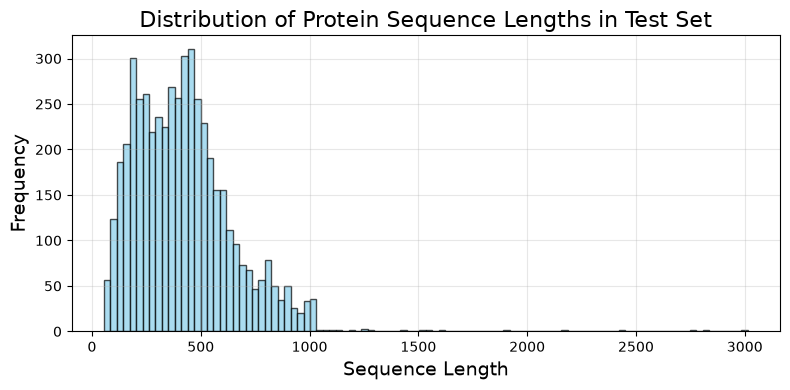

In [9]:
# df_testのSequence長分布の確認
plt.figure(figsize=(8, 4))
plt.hist(df_test['Length'], bins=100, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Protein Sequence Lengths in Test Set', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()